# Diabetes MLP Classification


In [2]:
from pathlib import Path
import os
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

working_directory = Path.cwd().resolve()
project_directory = working_directory.parent if working_directory.name == "notebooks" else working_directory
data_root = Path(os.environ.get("DIABETES_DATA_DIR", project_directory / "data"))
tr_pth = data_root / "train_data.csv"
te_pth = data_root / "test_data.csv"

missing_paths = [str(path) for path in (tr_pth, te_pth) if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "The diabetes CSV files are not distributed in this repository. "
        "Set DIABETES_DATA_DIR to a lawful local dataset copy. "
        f"Missing: {missing_paths}"
    )


# Preprocessing


 TRAIN DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               614 non-null    int64  
 1   Glucose                   614 non-null    int64  
 2   BloodPressure             614 non-null    int64  
 3   SkinThickness             614 non-null    int64  
 4   Insulin                   614 non-null    int64  
 5   BMI                       614 non-null    float64
 6   DiabetesPedigreeFunction  614 non-null    float64
 7   Age                       614 non-null    int64  
 8   Outcome                   614 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 43.3 KB


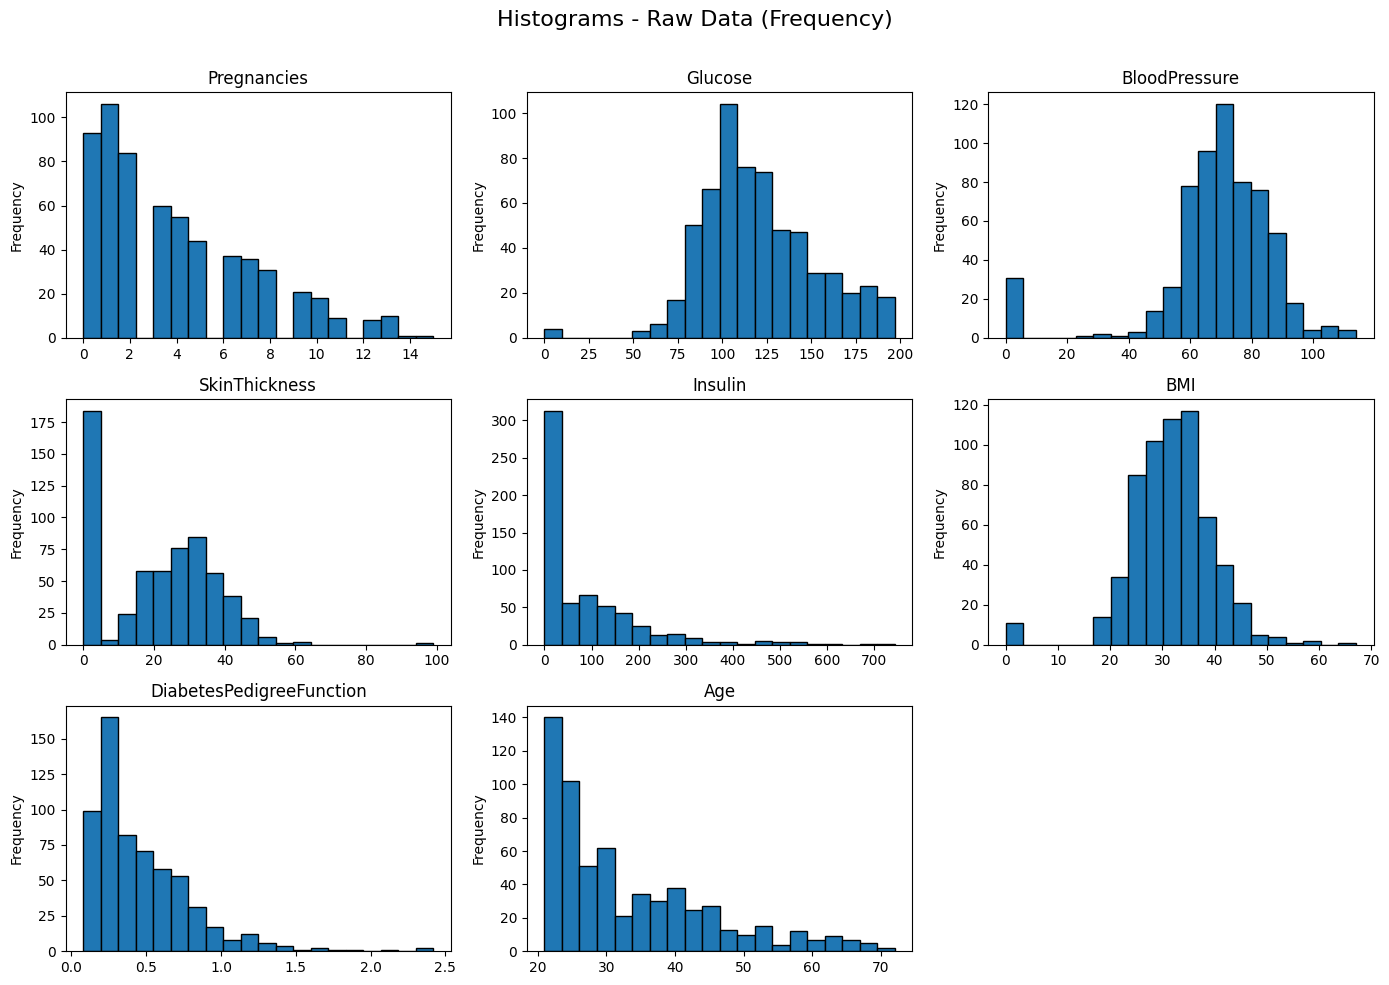

C:\Users\HP\AppData\Local\Temp\ipykernel_3600\2063301694.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tr_0[c], tr_1[c]], labels=["0", "1"])
C:\Users\HP\AppData\Local\Temp\ipykernel_3600\2063301694.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tr_0[c], tr_1[c]], labels=["0", "1"])
C:\Users\HP\AppData\Local\Temp\ipykernel_3600\2063301694.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tr_0[c], tr_1[c]], labels=["0", "1"])
C:\Users\HP\AppData\Local\Temp\ipykernel_3600\2063301694.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been ren

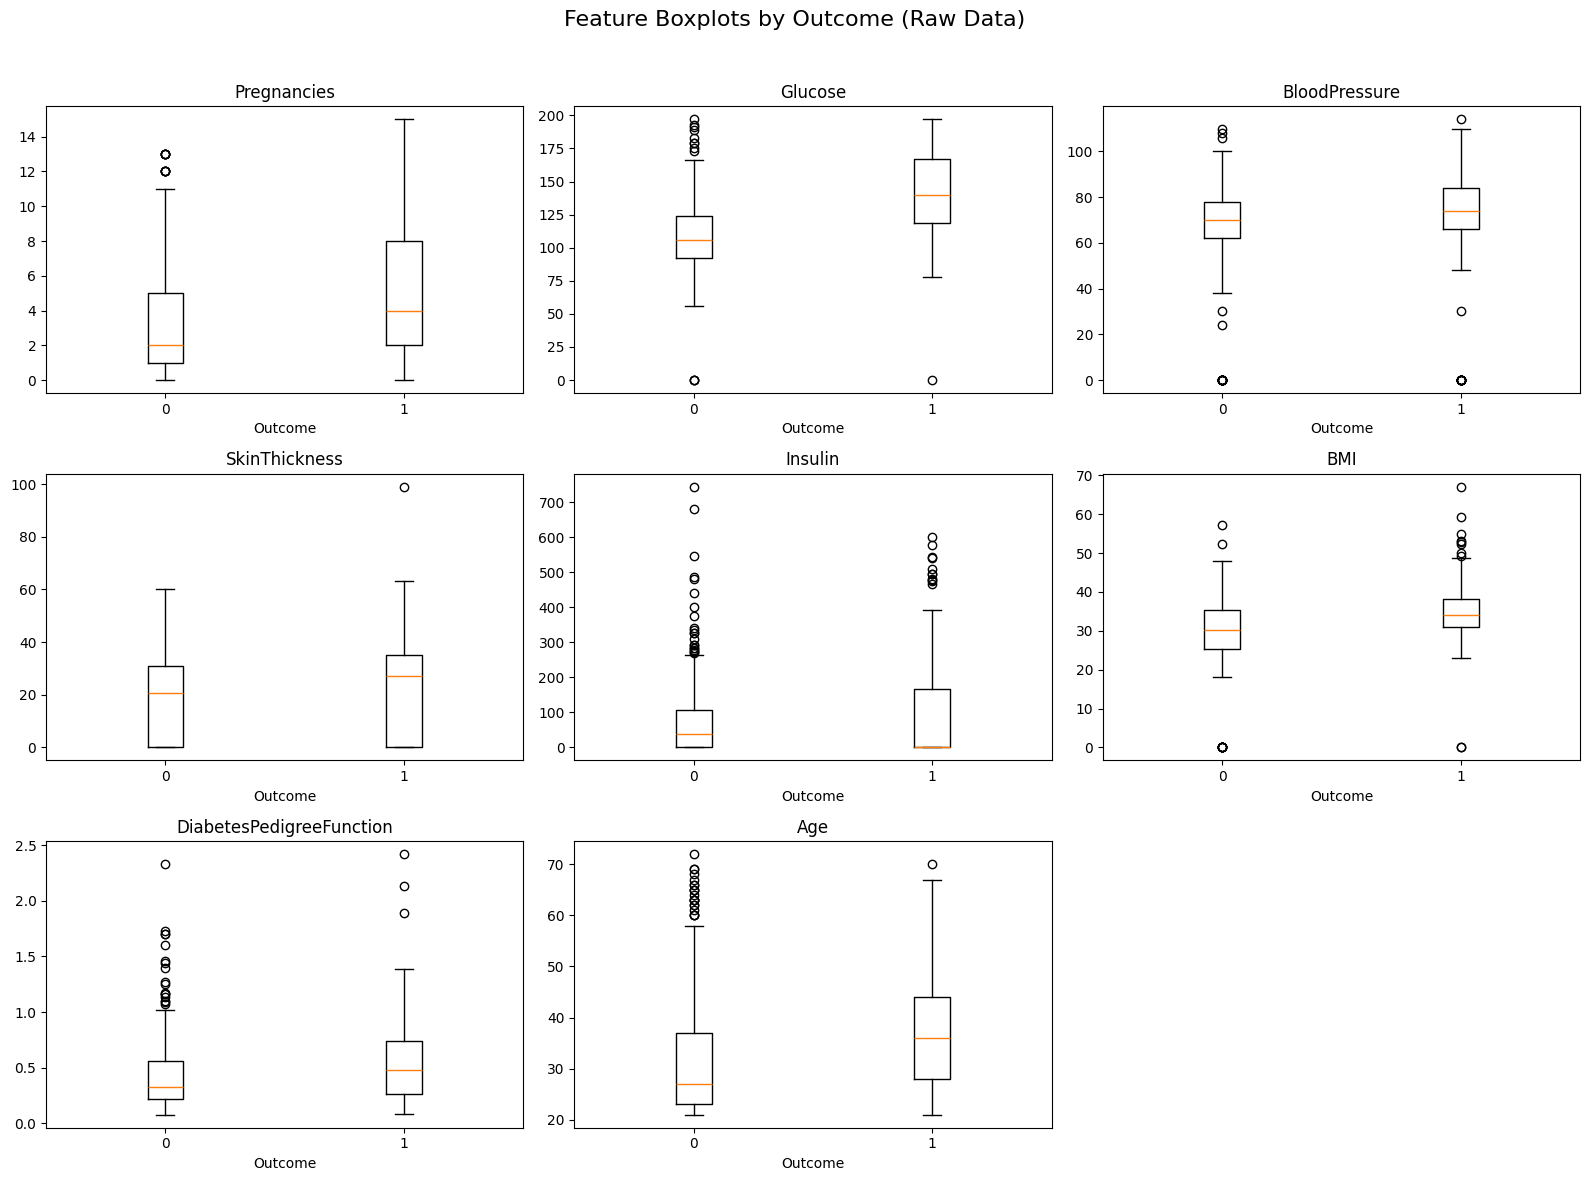

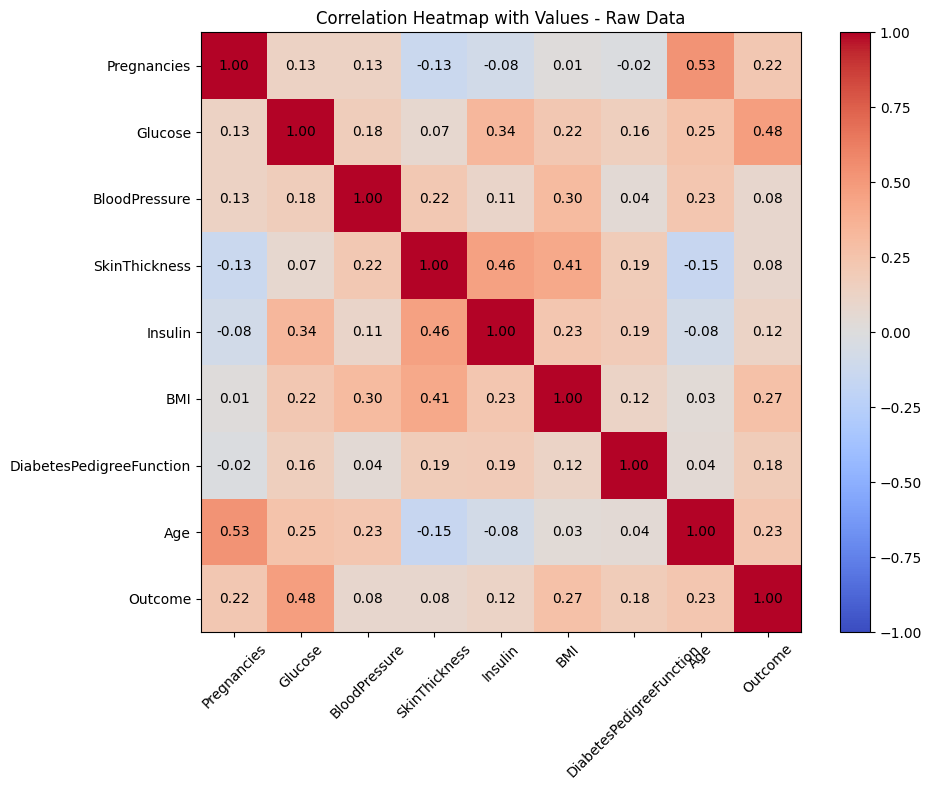


 Correlation Ranking with Outcome (Raw):

Outcome                     1.000000
Glucose                     0.475325
BMI                         0.272149
Age                         0.233461
Pregnancies                 0.222939
DiabetesPedigreeFunction    0.182245
Insulin                     0.124408
BloodPressure               0.082771
SkinThickness               0.078982
Name: Outcome, dtype: float64

CLEAN DATA INFO
<class 'pandas.core.frame.DataFrame'>
Index: 599 entries, 0 to 613
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               599 non-null    int64  
 1   Glucose                   599 non-null    int64  
 2   BloodPressure             599 non-null    float64
 3   SkinThickness             599 non-null    float64
 4   Insulin                   599 non-null    int64  
 5   BMI                       599 non-null    float64
 6   DiabetesPedigreeFunction  599 non

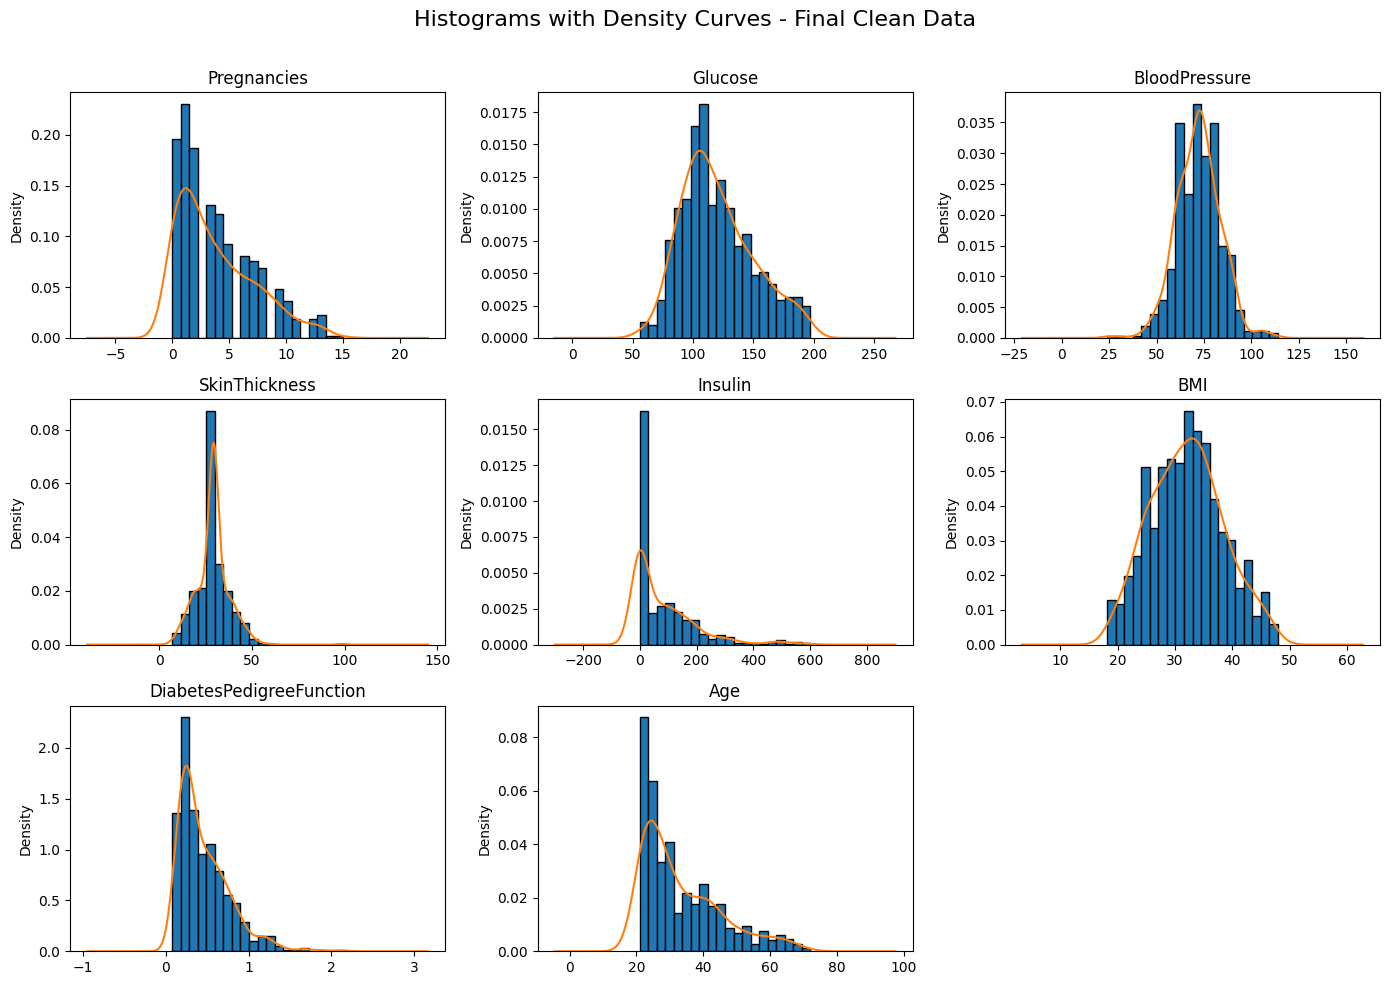

C:\Users\HP\AppData\Local\Temp\ipykernel_3600\2063301694.py:130: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dfx_0[c].dropna(), dfx_1[c].dropna()], labels=["0", "1"])
C:\Users\HP\AppData\Local\Temp\ipykernel_3600\2063301694.py:130: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dfx_0[c].dropna(), dfx_1[c].dropna()], labels=["0", "1"])
C:\Users\HP\AppData\Local\Temp\ipykernel_3600\2063301694.py:130: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dfx_0[c].dropna(), dfx_1[c].dropna()], labels=["0", "1"])
C:\Users\HP\AppData\Local\Temp\ipykernel_3600\2063301694.py:130: MatplotlibDepr

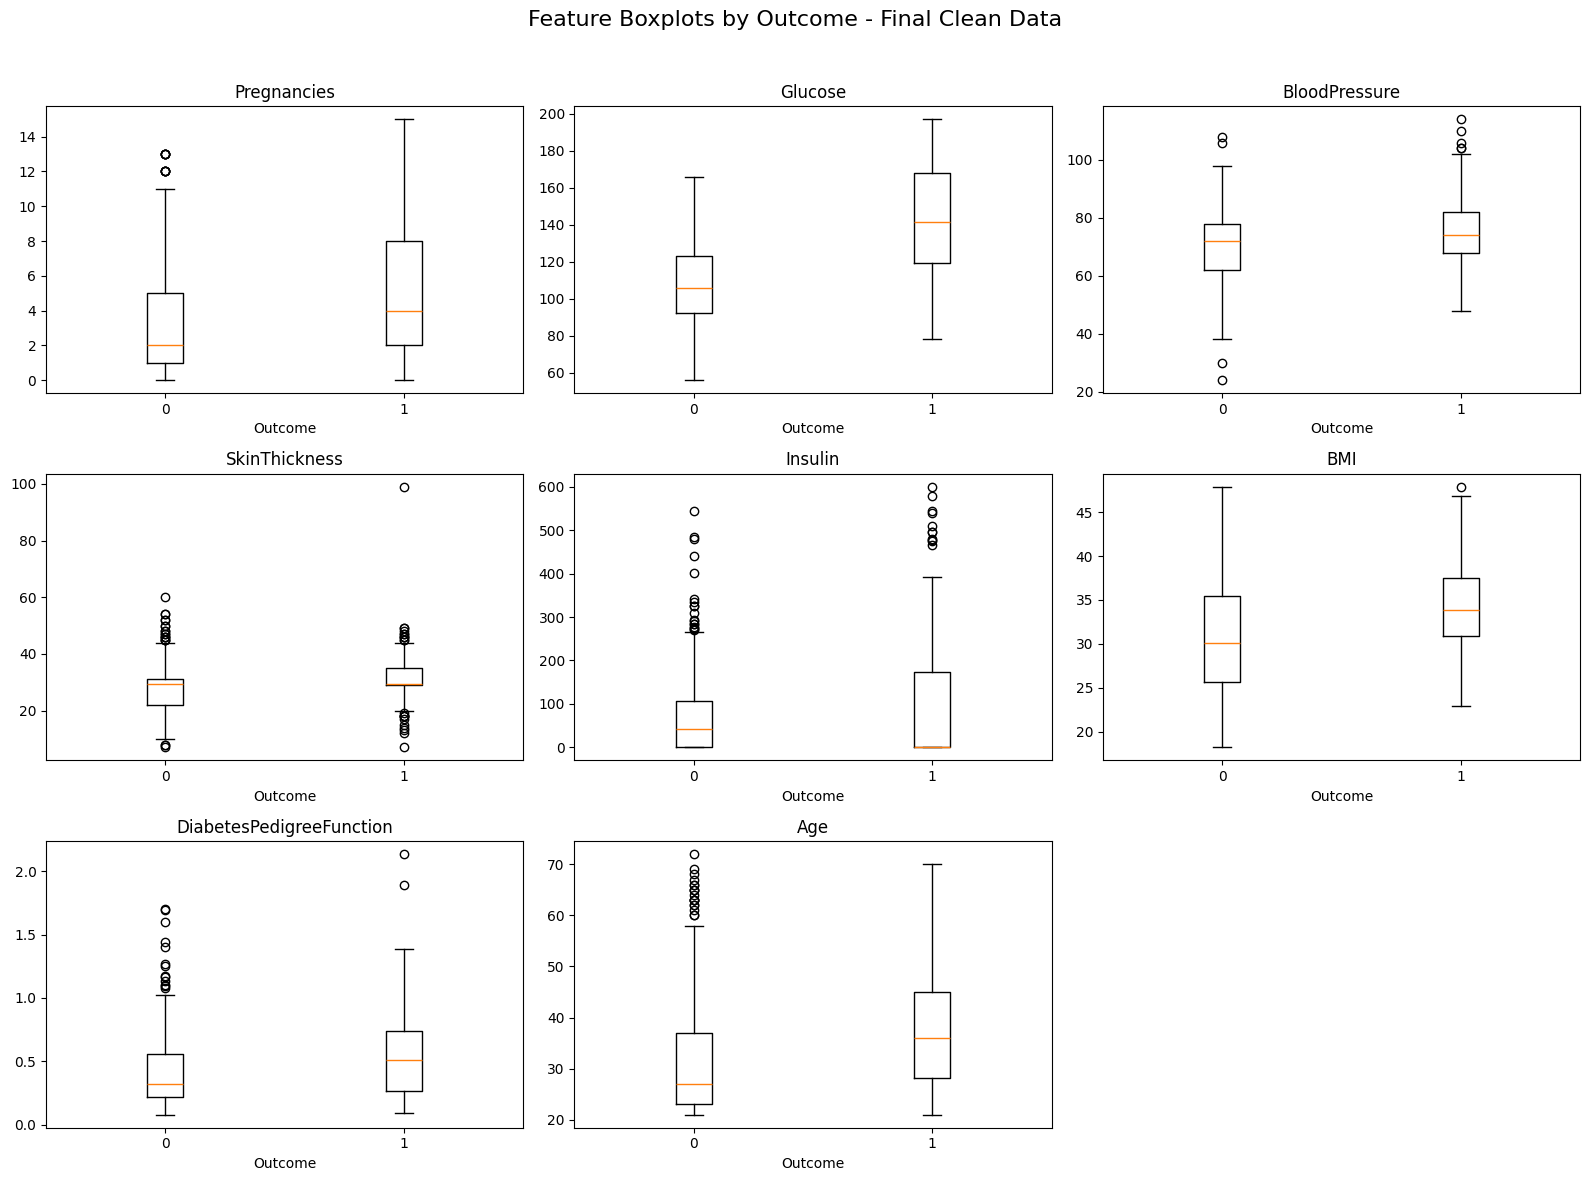

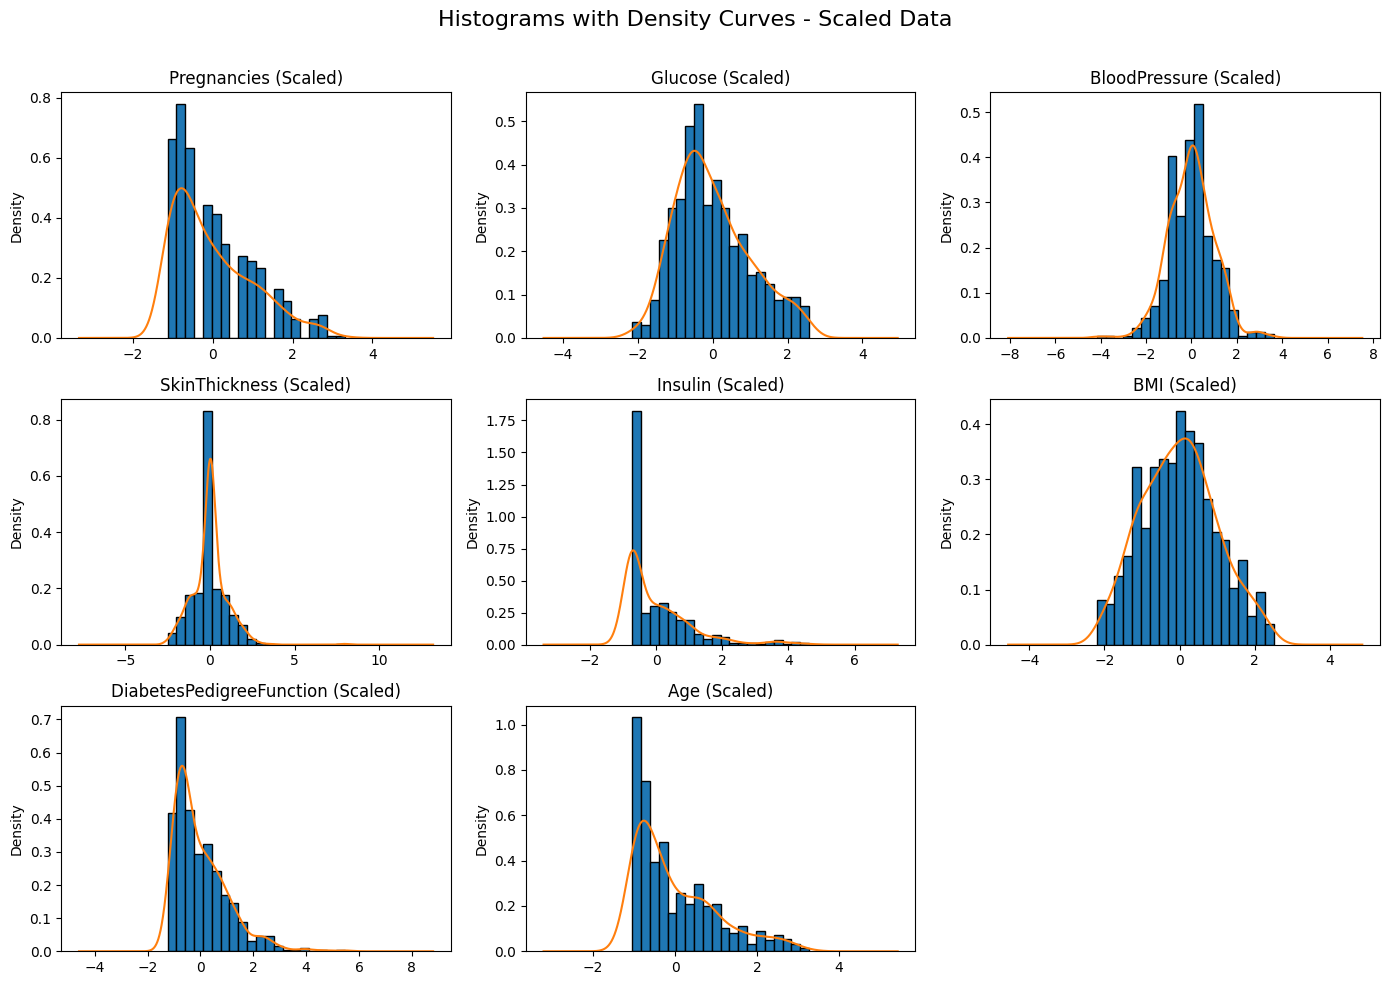


 TRAIN-VALIDATION SPLIT COMPLETE
Train set size: (463, 8)
Validation set size: (116, 8)

Train class balance:
 Outcome
0    0.658747
1    0.341253
Name: proportion, dtype: float64

Validation class balance:
 Outcome
0    0.655172
1    0.344828
Name: proportion, dtype: float64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# DATA LOADING
# Paths are configured in the preceding setup cell.

df_tr = pd.read_csv(tr_pth)   
df_te = pd.read_csv(te_pth)   

print("\n TRAIN DATA INFO")
df_tr.info()                  


ft_cols = [c for c in df_tr.columns if c != "Outcome"]

# RAW DATA VISUALS

plt.figure(figsize=(14, 10))
for i, c in enumerate(ft_cols):
    plt.subplot(3, 3, i + 1)
    df_tr[c].plot(kind='hist', bins=20, edgecolor='black')  #  frequency histogram
    plt.title(c)
    plt.tight_layout()

plt.suptitle("Histograms - Raw Data (Frequency)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# split raw by label for class-wise boxplots
tr_0 = df_tr[df_tr["Outcome"] == 0]   
tr_1 = df_tr[df_tr["Outcome"] == 1]   

plt.figure(figsize=(16, 12))          
for i, c in enumerate(ft_cols):
    plt.subplot(3, 3, i + 1)
    plt.boxplot([tr_0[c], tr_1[c]], labels=["0", "1"]) 
    plt.title(c); plt.xlabel("Outcome")
    plt.tight_layout()
plt.suptitle("Feature Boxplots by Outcome (Raw Data)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# RAW CORRELATION HEATMAP & RANKING

cr_raw = df_tr.corr()               

plt.figure(figsize=(10, 8))
img = plt.imshow(cr_raw, cmap="coolwarm", vmin=-1, vmax=1)  
plt.colorbar(img)
plt.xticks(range(len(cr_raw)), cr_raw.columns, rotation=45) 
plt.yticks(range(len(cr_raw)), cr_raw.index)
for r in range(cr_raw.shape[0]):
    for k in range(cr_raw.shape[1]):
        plt.text(k, r, f"{cr_raw.iloc[r, k]:.2f}", ha='center', va='center', color='black')  
plt.title("Correlation Heatmap with Values - Raw Data")
plt.tight_layout()
plt.show()

# rank features by correlation with target to guide intuition (not feature selection here)
print("\n Correlation Ranking with Outcome (Raw):\n")
print(cr_raw["Outcome"].sort_values(ascending=False))


# ZERO HANDLING (rules from your final pipeline)

df_cln = df_tr.copy()                                                
df_cln = df_cln[(df_cln["Glucose"] != 0) & (df_cln["BMI"] != 0)]       

bp_mu = df_cln.loc[df_cln["BloodPressure"] != 0, "BloodPressure"].mean()  
sk_mu = df_cln.loc[df_cln["SkinThickness"] != 0, "SkinThickness"].mean()  

df_cln["BloodPressure"] = df_cln["BloodPressure"].replace(0, bp_mu)   
df_cln["SkinThickness"] = df_cln["SkinThickness"].replace(0, sk_mu)    

print("\nCLEAN DATA INFO")
df_cln.info()                                                     


# CLASS-WISE OUTLIER REMOVAL 

df_fin = df_cln.copy()  

def _rm_iqr_by_cls(dfx, col):
    
    for yv in [0, 1]:
        sub = dfx[dfx["Outcome"] == yv]         
        q1 = sub[col].quantile(0.25)                
        q3 = sub[col].quantile(0.75)              
        iqr = q3 - q1                        
        lo = q1 - 1.5 * iqr                         
        hi = q3 + 1.5 * iqr                        
        dfx = dfx[~((dfx["Outcome"] == yv) & ((dfx[col] < lo) | (dfx[col] > hi)))] 
    return dfx

for _c in ["Glucose", "BMI"]:
    df_fin = _rm_iqr_by_cls(df_fin, _c)            
    print(f"Class-wise outliers removed for: {_c}")

print("\nFINAL CLASS-WISE CLEANED DATA INFO")
df_fin.info()                                      


# VISUALS ON FINAL CLEAN DATA

dfx = df_fin.copy()                      

plt.figure(figsize=(14, 10))                         
for i, c in enumerate(ft_cols):
    plt.subplot(3, 3, i + 1)
    dfx[c].plot(kind='hist', bins=20, density=True, edgecolor='black')  
    try:
        dfx[c].plot(kind='kde')                    
    except:
        pass
    plt.title(c)
    plt.tight_layout()
plt.suptitle("Histograms with Density Curves - Final Clean Data", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

dfx_0 = dfx[dfx["Outcome"] == 0]                   
dfx_1 = dfx[dfx["Outcome"] == 1]                 

plt.figure(figsize=(16, 12))
for i, c in enumerate(ft_cols):
    plt.subplot(3, 3, i + 1)
    plt.boxplot([dfx_0[c].dropna(), dfx_1[c].dropna()], labels=["0", "1"])  
    plt.title(c); plt.xlabel("Outcome")
    plt.tight_layout()
plt.suptitle("Feature Boxplots by Outcome - Final Clean Data", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# SCALING 

from sklearn.preprocessing import StandardScaler

X_mat = df_fin[ft_cols]                 
y_vec = df_fin["Outcome"]           
sc = StandardScaler()                   
X_sc = sc.fit_transform(X_mat)         
Xsc_df = pd.DataFrame(X_sc, columns=ft_cols) 

# histograms of scaled data for quick sanity check
plt.figure(figsize=(14, 10))
for i, c in enumerate(ft_cols):
    plt.subplot(3, 3, i + 1)
    Xsc_df[c].plot(kind='hist', bins=20, density=True, edgecolor='black')  
    try:
        Xsc_df[c].plot(kind='kde')                                        
    except:
        pass
    plt.title(c + " (Scaled)")
    plt.tight_layout()
plt.suptitle("Histograms with Density Curves - Scaled Data", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


# TRAIN / VALIDATION SPLIT 

from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(  # 80/20 split with stratification
    Xsc_df, y_vec, test_size=0.2, random_state=42, stratify=y_vec
)

print("\n TRAIN-VALIDATION SPLIT COMPLETE")
print("Train set size:", X_tr.shape)
print("Validation set size:", X_va.shape)
print("\nTrain class balance:\n", y_tr.value_counts(normalize=True))
print("\nValidation class balance:\n", y_va.value_counts(normalize=True))


# Model Implementation


 Training Started...

Epoch    TrainLoss     ValLoss      ValAcc     ValF1    ValAUC
1           0.9287      0.8887       0.647     0.047     0.744
2           0.8658      0.8357       0.767     0.571     0.820
3           0.8085      0.7835       0.759     0.659     0.828
4           0.7572      0.7319       0.733     0.644     0.835
5           0.7090      0.6887       0.716     0.629     0.839
6           0.6724      0.6597       0.716     0.645     0.845
7           0.6579      0.6398       0.733     0.674     0.850
8           0.6405      0.6276       0.733     0.667     0.858
9           0.6296      0.6195       0.733     0.659     0.861
10          0.6280      0.6099       0.767     0.697     0.868
11          0.6153      0.6073       0.759     0.696     0.869
12          0.6049      0.6033       0.767     0.703     0.871
13          0.6156      0.6004       0.767     0.703     0.871
14          0.6152      0.5993       0.767     0.703     0.873
15          0.5839      0.5984  

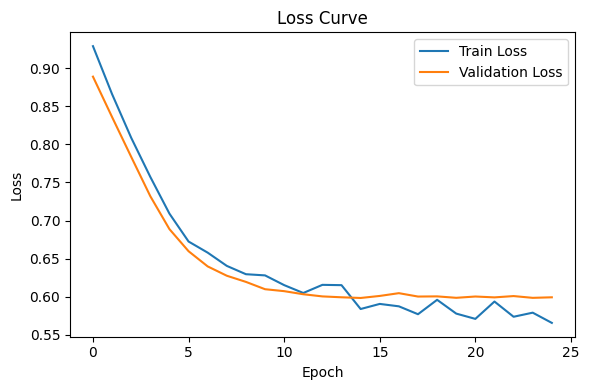

In [4]:

# CLEAN & PROFESSIONAL MLP CLASSIFICATION 

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# TRAINING CONFIG

BSZ   = 32      
EP    = 80      
LRATE = 0.001   
H1    = 64      
H2    = 32     
DROP  = 0.2     
PAT   = 10      


# TENSORS & LOADERS

Xt_t = torch.tensor(X_tr.values, dtype=torch.float32)    
yt_t = torch.tensor(y_tr.values.reshape(-1, 1), dtype=torch.float32) 
Xv_t = torch.tensor(X_va.values, dtype=torch.float32)      
yv_t = torch.tensor(y_va.values.reshape(-1, 1), dtype=torch.float32) 

ds_tr = TensorDataset(Xt_t, yt_t)                          
ds_va = TensorDataset(Xv_t, yv_t)

dl_tr = DataLoader(ds_tr, batch_size=BSZ, shuffle=True)   
dl_va = DataLoader(ds_va, batch_size=BSZ, shuffle=False)  


# MODEL DEFINITION

class MNet(nn.Module):

    def __init__(self, in_dim, h1, h2, dr):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1), nn.ReLU(), nn.Dropout(dr),
            nn.Linear(h1, h2),    nn.ReLU(), nn.Dropout(dr),
            nn.Linear(h2, 1)  
        )
    def forward(self, x):
        return self.net(x)

in_dim = X_tr.shape[1]                                     
mdl = MNet(in_dim, H1, H2, DROP)                           

# class imbalance: weight positive class to mitigate skew
pos_ct = int((y_tr.values == 1).sum())                   
neg_ct = int((y_tr.values == 0).sum())               
w_pos  = torch.tensor([neg_ct / max(pos_ct, 1)], dtype=torch.float32)  

crit = nn.BCEWithLogitsLoss(pos_weight=w_pos)             
opt  = optim.Adam(mdl.parameters(), lr=LRATE)            


# EVALUATION HELPER

def eval_loop(loader):
  
    mdl.eval()
    y_true, y_pred, y_prob = [], [], []
    tot_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            lg = mdl(xb)                                
            ls = crit(lg, yb)                              
            tot_loss += ls.item() * xb.size(0)             
            pr = torch.sigmoid(lg).cpu().numpy().ravel()   
            y_prob.extend(pr)                            
            y_true.extend(yb.cpu().numpy().ravel())        
            y_pred.extend((pr >= 0.5).astype(int))         
    avg = tot_loss / len(loader.dataset)                   
    return {
        "loss": avg,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob)
    }


# TRAIN BASELINE WITH EARLY STOP

tr_ls, va_ls = [], []             
best_val = float("inf")             
best_st  = None                    
stall    = 0                     

print("\n Training Started...\n")
print(f"{'Epoch':<6}{'TrainLoss':>12}{'ValLoss':>12}{'ValAcc':>12}{'ValF1':>10}{'ValAUC':>10}")

for ep in range(1, EP + 1):
    mdl.train()
    run = 0.0
    for xb, yb in dl_tr:
        opt.zero_grad()             
        lg = mdl(xb)             
        ls = crit(lg, yb)          
        ls.backward()              
        opt.step()                 
        run += ls.item() * xb.size(0)
    tr_loss = run / len(dl_tr.dataset) 

    va_m = eval_loop(dl_va)          
    tr_ls.append(tr_loss); va_ls.append(va_m["loss"])

    print(f"{ep:<6}{tr_loss:>12.4f}{va_m['loss']:>12.4f}{va_m['accuracy']:>12.3f}{va_m['f1']:>10.3f}{va_m['auc']:>10.3f}")

    if va_m["loss"] < best_val:        
        best_val = va_m["loss"]
        best_st  = mdl.state_dict()
        stall = 0
    else:
        stall += 1
        if stall >= PAT:
            print("\n Early Stopping Triggered!")
            break

mdl.load_state_dict(best_st)           

print("\n Training Complete!\n")
va_final = eval_loop(dl_va)            
print(" Final Validation Results")
print("-"*60)
for k, v in va_final.items():
    print(f"{k:<10}: {v:.4f}")
print("-"*60)

# plot loss curves for baseline
plt.figure(figsize=(6,4))
plt.plot(tr_ls, label="Train Loss")
plt.plot(va_ls, label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.tight_layout(); plt.show()

# Experiments


 Starting Exp1_Small  -> H1:32, H2:16, LR:0.01, Drop:0.2


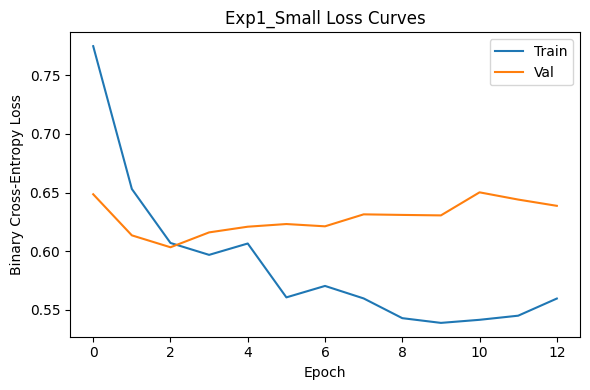


 Starting Exp2_Medium_Baseline  -> H1:64, H2:32, LR:0.001, Drop:0.2


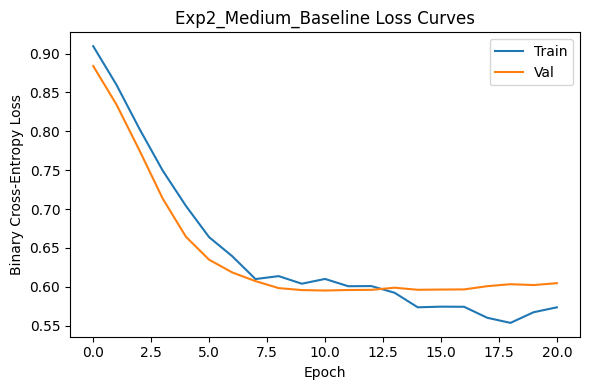


 Starting Exp3_Large  -> H1:128, H2:64, LR:0.0005, Drop:0.3


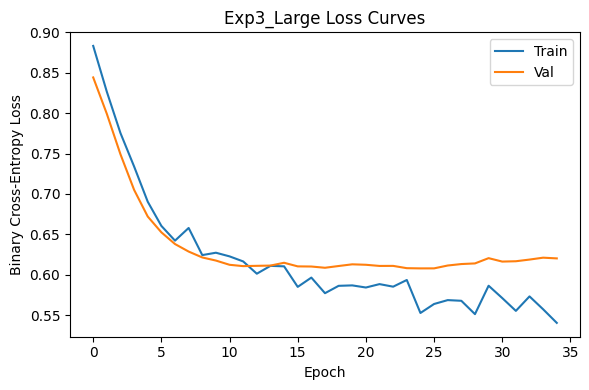


 FINAL RESULTS SUMMARY (Validation Set)

               Model     Loss  Accuracy  Precision  Recall       F1      AUC
          Exp1_Small 0.638776  0.775862   0.629630    0.85 0.723404 0.864474
Exp2_Medium_Baseline 0.604775  0.758621   0.615385    0.80 0.695652 0.864474
          Exp3_Large 0.620292  0.784483   0.641509    0.85 0.731183 0.861184


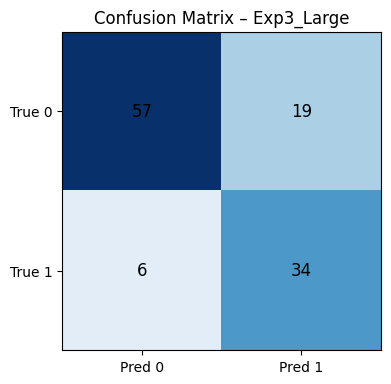

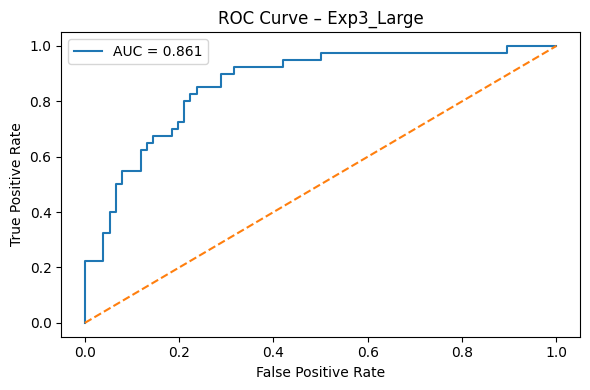


 FINAL TEST RESULTS

Accuracy : 0.7255
Precision: 0.6119
Recall   : 0.7193
F1-score : 0.6613
AUC      : 0.8427


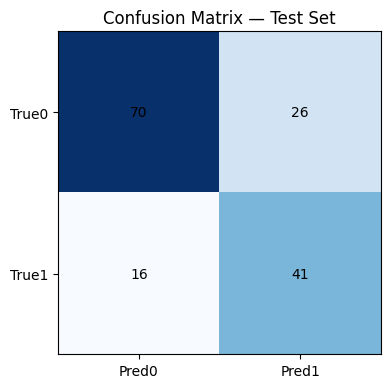

In [6]:

# MULTI-EXPERIMENT MLPs (clean output, plots & results table)

RESULTS = []        
WTS = {}               

def _eval_model_for_table(mnet, ld):
    
    mnet.eval()
    yh, yp, pr = [], [], []
    tot = 0.0
    with torch.no_grad():
        for xb, yb in ld:
            lg = mnet(xb)
            ls = crit(lg, yb)
            tot += ls.item() * xb.size(0)
            p = torch.sigmoid(lg).cpu().numpy().ravel()
            pr.extend(p)
            yh.extend(yb.cpu().numpy().ravel())
            yp.extend((p >= 0.5).astype(int))
    avg = tot / len(ld.dataset)
    return {
        "loss": avg,
        "accuracy": accuracy_score(yh, yp),
        "precision": precision_score(yh, yp, zero_division=0),
        "recall": recall_score(yh, yp, zero_division=0),
        "f1": f1_score(yh, yp, zero_division=0),
        "auc": roc_auc_score(yh, pr),
        "y_true": np.array(yh),
        "y_pred": np.array(yp),
        "y_prob": np.array(pr)
    }

EXPS = [
    ("Exp1_Small",            32,  16, 0.01,   0.2),
    ("Exp2_Medium_Baseline",  64,  32, 0.001,  0.2),
    ("Exp3_Large",           128,  64, 0.0005, 0.3),
]

for nm, h1x, h2x, lr_x, dr_x in EXPS:
    print(f"\n Starting {nm}  -> H1:{h1x}, H2:{h2x}, LR:{lr_x}, Drop:{dr_x}")

    mexp = MNet(in_dim, h1x, h2x, dr_x)                 
    optx = optim.Adam(mexp.parameters(), lr=lr_x)       
    best_l = float("inf")                               
    wait_x = 0                                          
    tr_hist, va_hist = [], []                        

    for ep in range(1, 81):                            
        mexp.train()
        rsum = 0.0
        for xb, yb in dl_tr:
            optx.zero_grad()
            lgi = mexp(xb)
            lsi = crit(lgi, yb)
            lsi.backward()
            optx.step()
            rsum += lsi.item() * xb.size(0)
        tr_hist.append(rsum / len(dl_tr.dataset))       

        mexp_m = _eval_model_for_table(mexp, dl_va)     
        va_hist.append(mexp_m["loss"])

        if mexp_m["loss"] < best_l:                    
            best_l = mexp_m["loss"]
            WTS[nm] = mexp.state_dict()                
            wait_x = 0
        else:
            wait_x += 1
            if wait_x >= 10:                            
                break

    mexp.load_state_dict(WTS[nm])                      
    fin = _eval_model_for_table(mexp, dl_va)           
    fin["model"] = nm
    RESULTS.append(fin)

    # plot loss curves for each experiment (for report)
    plt.figure(figsize=(6,4))
    plt.plot(tr_hist, label="Train")
    plt.plot(va_hist, label="Val")
    plt.title(f"{nm} Loss Curves")
    plt.xlabel("Epoch"); plt.ylabel("Binary Cross-Entropy Loss")
    plt.legend(); plt.tight_layout(); plt.show()

# tabulate experiment results
res_df = pd.DataFrame([{
    "Model": r["model"], "Loss": r["loss"], "Accuracy": r["accuracy"],
    "Precision": r["precision"], "Recall": r["recall"], "F1": r["f1"], "AUC": r["auc"]
} for r in RESULTS])

print("\n FINAL RESULTS SUMMARY (Validation Set)\n")
print(res_df.to_string(index=False))


# CONFUSION MATRIX & ROC FOR SELECTED BEST (Exp3_Large)

best_nm = "Exp3_Large"                                  
best_r  = [r for r in RESULTS if r["model"] == best_nm][0]
y_t = best_r["y_true"]; y_p = best_r["y_pred"]; y_pb = best_r["y_prob"]

# simple confusion matrix implementation
cm = np.zeros((2, 2), dtype=int)
for t, p in zip(y_t, y_p):
    cm[int(t), int(p)] += 1

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues", vmin=0)
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)
plt.xticks([0,1], ["Pred 0","Pred 1"])
plt.yticks([0,1], ["True 0","True 1"])
plt.title(f"Confusion Matrix – {best_nm}")
plt.tight_layout(); plt.show()

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_t, y_pb)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {best_r['auc']:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve – {best_nm}")
plt.legend(); plt.tight_layout(); plt.show()



#  TEST SET EVALUATION — SAME CLEANING & SCALING RULES


df_te_cln = df_te.copy() 

# drop zero rows for Glucose/BMI (same rule as training)
df_te_cln = df_te_cln[(df_te_cln["Glucose"] != 0) & (df_te_cln["BMI"] != 0)]

# impute zeros in BP & SkinThickness using training means for consistency
df_te_cln["BloodPressure"]  = df_te_cln["BloodPressure"].replace(0, bp_mu)
df_te_cln["SkinThickness"]  = df_te_cln["SkinThickness"].replace(0, sk_mu)

# apply SAME scaler (no refit!) to test features
X_te_sc = sc.transform(df_te_cln[ft_cols])

# rebuild the chosen best architecture and load stored best weights from experiments
best_mdl = MNet(in_dim, 128, 64, 0.3)     
best_mdl.load_state_dict(WTS[best_nm])   

best_mdl.eval()
with torch.no_grad():
    lg_te = best_mdl(torch.tensor(X_te_sc, dtype=torch.float32))        
    pb_te = torch.sigmoid(lg_te).cpu().numpy().ravel()                   
    pr_te = (pb_te >= 0.5).astype(int)                                  

y_te_true = df_te_cln["Outcome"].values                                 

# compute test metrics for final reporting
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
acc_te = accuracy_score(y_te_true, pr_te)
pre_te = precision_score(y_te_true, pr_te, zero_division=0)
rec_te = recall_score(y_te_true, pr_te, zero_division=0)
f1_te  = f1_score(y_te_true, pr_te, zero_division=0)
auc_te = roc_auc_score(y_te_true, pb_te)

print("\n FINAL TEST RESULTS\n")
print(f"Accuracy : {acc_te:.4f}")
print(f"Precision: {pre_te:.4f}")
print(f"Recall   : {rec_te:.4f}")
print(f"F1-score : {f1_te:.4f}")
print(f"AUC      : {auc_te:.4f}")

# confusion matrix for test set
cm_te = np.zeros((2,2), dtype=int)
for t, p in zip(y_te_true, pr_te):
    cm_te[int(t), int(p)] += 1

plt.figure(figsize=(4,4))
plt.imshow(cm_te, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_te[i,j], ha="center", va="center", color="black")
plt.xticks([0,1], ["Pred0","Pred1"])
plt.yticks([0,1], ["True0","True1"])
plt.title("Confusion Matrix — Test Set")
plt.tight_layout(); plt.show()


## Interpretation and limitations

Validation experiments were used to select the large MLP because it achieved the highest validation ROC-AUC (0.8704). The final evaluation on 153 cleaned test records achieved 0.7451 accuracy and 0.8480 ROC-AUC. These results are specific to the supplied academic dataset and preprocessing design and do not establish clinical validity.
